<a href="https://colab.research.google.com/github/ZakParkinson04/Using-Chest-X-rays-to-diagnose-diseases-and-anomalies-an-explainable-AI-Model-for-medical-Diagnosis/blob/main/ResNet50_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This cell imports necessary libraries and mounts Google Drive.
from google.colab import drive
drive.mount('/content/drive')

import os
import shutil
import random
import pathlib
from pathlib import Path
import zipfile

import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import numpy as np

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm

import matplotlib.pyplot as plt

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# This cell defines project directories and the path to the zipped dataset.
Project_Direct = "/content/drive/MyDrive/Dissertation Chest XAI Diagnosis Support"

Raw_Combined_Data_Direct = os.path.join(Project_Direct, "data/raw/Combined_Deduplicated")
Output_Direct = os.path.join(Project_Direct, "outputs")

Zip_Path = os.path.join(Project_Direct, "data/processed/Split.zip")



print("Raw combined data:", Raw_Combined_Data_Direct)
print("Outputs:", Output_Direct)

Raw combined data: /content/drive/MyDrive/Dissertation Chest XAI Diagnosis Support/data/raw/Combined_Deduplicated
Processed data split: /content/drive/MyDrive/Dissertation Chest XAI Diagnosis Support/data/processed/split
Outputs: /content/drive/MyDrive/Dissertation Chest XAI Diagnosis Support/outputs


In [ ]:
# This cell sets up global parameters for model training.
Image_Size = 224
Batch_Size = 64
Num_Epochs = 10
Learning_Rate = 1e-4

Bench_Model = "resnet50"
Pretrained = True

In [ ]:
# This cell defines image transformation pipelines for training and testing datasets.
Train_transform = transforms.Compose([
    transforms.Resize((Image_Size, Image_Size)),
    transforms.Grayscale(num_output_channels = 3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])
])

Test_transform = transforms.Compose([
    transforms.Resize((Image_Size, Image_Size)),
    transforms.Grayscale(num_output_channels = 3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])
])

In [ ]:
# This cell handles the data loading process, copying and unzipping the dataset.
Local_Data_Dir = "/content/chest_xray_split"
Local_Zip_Path = "/content/chest_xray_split_Zipped.zip"

if Path(Local_Data_Dir).exists():
  print("Removing incomplete existing directory to force re-extraction.")
  shutil.rmtree(Local_Data_Dir)

print("Copying Zip from Drive to Colab.")
shutil.copy2(Zip_Path, Local_Zip_Path)

print("Unzipping Data.")
with zipfile.ZipFile(Local_Zip_Path, "r") as zip_ref:
  zip_ref.extractall(Local_Data_Dir)

print("Data unzipped at:", Local_Data_Dir)
print("Contents of extracted folder:", os.listdir(Local_Data_Dir))

# Automatically adjust if the unzipped folder contains 'split_updated' as the root directory
if "split_updated" in os.listdir(Local_Data_Dir):
    Local_Data_Dir = os.path.join(Local_Data_Dir, "split_updated")

TRAIN_DIR = os.path.join(Local_Data_Dir, "train")
VAL_DIR = os.path.join(Local_Data_Dir, "val")
TEST_DIR = os.path.join(Local_Data_Dir, "test")

print("\nTrain exists:", Path(TRAIN_DIR).exists())
print("Val exists:", Path(VAL_DIR).exists())
print("Test exists:", Path(TEST_DIR).exists())

Copying Zip from Drive to Colab.
Unzipping Data.
Data unzipped at: /content/chest_xray_split
Contents of extracted folder: ['split_updated']

Train exists: True
Val exists: True
Test exists: True


In [ ]:
# This cell creates ImageFolder datasets and DataLoaders for training, validation, and testing.
Training_Dir = os.path.join(Data_Direct, "train")
Val_Dir = os.path.join(Data_Direct, "val")
Testing_Dir = os.path.join(Data_Direct, "test")

Train_Data = datasets.ImageFolder(TRAIN_DIR, transform=Train_transform)
Val_Data = datasets.ImageFolder(VAL_DIR, transform=Test_transform)
Test_Data = datasets.ImageFolder(TEST_DIR, transform=Test_transform)

Num_Classes = len(Train_Data.classes)
Class_Names = Train_Data.classes

# Set num_workers to half the number of CPU cores for optimal performance
# This helps balance CPU data loading with GPU computation.

Traning_Load = DataLoader(Train_Data,
                          batch_size=Batch_Size,
                          shuffle=True,
                          pin_memory=True,
                          num_workers= 2
                          )

Validation_Load = DataLoader(Val_Data,
                             batch_size=Batch_Size,
                             shuffle=False,
                             pin_memory=True,
                             num_workers= 2
                             )

Test_Load = DataLoader(Test_Data,
                       batch_size=Batch_Size,
                       shuffle=False,
                       pin_memory=True,
                       num_workers= 2
                       )

print("Class Names:", Class_Names)
print("Number of Classes:", Num_Classes)
print("Train images", len(Train_Data))
print("Val images", len(Val_Data))
print("Test images", len(Test_Data))

Class Names: ['COVID', 'Lung Cancer', 'Normal Split', 'Pneumonia', 'Tuberculosis']
Number of Classes: 5
Train images 4649
Val images 996
Test images 997


In [ ]:
# This cell verifies the existence of training, validation, and testing directories.
print("Train exists:", os.path.exists(Training_Dir))
print("Val exists:", os.path.exists(Val_Dir))
print("Test exists:", os.path.exists(Testing_Dir))

Train exists: True
Val exists: True
Test exists: True


In [ ]:
# This cell defines the resnet50 function to initialize a ResNet50 model.
def resnet50(Num_Classes, Pretrained = True):
  weights = models.ResNet50_Weights.DEFAULT if Pretrained else None
  Res_model = models.resnet50(weights=weights)

  in_features = Res_model.fc.in_features
  Res_model.fc = nn.Sequential(
      nn.Dropout(p=0.4),
      nn.Linear(in_features, 256),
      nn.ReLU(),
      nn.Dropout(p=0.3),
      nn.Linear(256, Num_Classes)
  )

  return Res_model

In [ ]:
# This cell defines functions for training a single epoch and validating the model.
def Train_One_Epoch(model, Train_Loader, Criterion, Optimizer, Device):
  model.train()

  Running_Loss= 0.0
  Correct = 0
  Total = 0

  for Images, Labels in tqdm(Train_Loader):
    Images = Images.to(Device)
    Labels = Labels.to(Device)

    ResNet_Optimizer.zero_grad()

    Outputs = model(Images)
    Loss = Criterion(Outputs, Labels)
    Loss.backward()
    Optimizer.step()

    Running_Loss += Loss.item()

    _, Predicted = torch.max(Outputs, 1)
    Total += Labels.size(0)
    Correct += (Predicted == Labels).sum().item()

  Epoch_Loss = Running_Loss / len(Train_Loader)
  Epoch_Accuracy = Correct / Total

  return Epoch_Loss, Epoch_Accuracy

  print("Epoch Loss:", Epoch_Loss)
  print("Epoch Accuracy:", Epoch_Accuracy)

def Validattion(model, Train_Loader, Criterion, Device):
  model.eval()

  Running_Loss = 0.0
  Correct = 0
  Total = 0

  with torch.no_grad():
    for Images, Labels in tqdm(Train_Loader):
      Images = Images.to(Device)
      Labels = Labels.to(Device)


      Outputs = model(Images)
      Loss = Criterion(Outputs, Labels)

      Running_Loss += Loss.item()

      _, Predicted = torch.max(Outputs, 1)
      Total += Labels.size(0)
      Correct += (Predicted == Labels).sum().item()

  Val_Loss = Running_Loss / len(Train_Loader)
  Val_Accuracy = Correct / Total

  return Val_Loss, Val_Accuracy

  print("Validation Loss:", Val_Loss)
  print("Validation Accuracy:", Val_Accuracy)

In [ ]:
# This cell initializes the model, loss function, optimizer, and training history.
Device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


ResNet_Model = resnet50(
    Num_Classes = Num_Classes,
    Pretrained = Pretrained
).to(Device)

Criterion = nn.CrossEntropyLoss()
ResNet_Optimizer = optim.Adam(
    ResNet_Model.parameters(),
    lr=Learning_Rate
)

ResNet_Hist = {
    "Train_Loss": [],
    "Train_Accuracy": [],
    "Val_Loss": [],
    "Val_Accuracy": []
}

In [ ]:
# This cell calculates and applies class weights for addressing class imbalance.
Train_Labels = [label for _, label in Train_Data.samples]

Class_Weights = compute_class_weight(
    "balanced",
    classes=np.arange(Num_Classes),
    y=Train_Labels
)

Class_Weights = torch.tensor(Class_Weights, dtype=torch.float).to(Device)

print("Class Names:", Class_Names)
print("Class Weights:", Class_Weights)

ResNet_Criterion = nn.CrossEntropyLoss(weight=Class_Weights)

Class Names: ['COVID', 'Lung Cancer', 'Normal Split', 'Pneumonia', 'Tuberculosis']
Class Weights: tensor([0.8889, 0.8923, 0.8609, 0.9364, 1.9053], device='cuda:0')


In [ ]:
# This cell configures the optimizer, learning rate scheduler, and best model saving path.
ResNet_Optimizer = optim.Adam(
    ResNet_Model.parameters(),
    lr=Learning_Rate,
    weight_decay=1e-4
)

ResNet_Scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    ResNet_Optimizer,
    mode = "min",
    factor = 0.5,
    patience = 2
)

Best_ResNet_Path = os.path.join(
    Output_Direct,
    "models/resnet/Benchmark_ResNet.pth"
)

os.makedirs(os.path.dirname(Best_ResNet_Path), exist_ok=True)

# Initialize Best_Val_Acc_ResNet with the validation accuracy from the first epoch
Best_Val_Acc_ResNet = 0.6225

In [ ]:
# This cell runs a preliminary test of the training loop for one epoch.
Test_Epochs = 1
for Epoch in range(Test_Epochs):
    print(f"Epoch {Epoch + 1}/{Test_Epochs}")
    Train_Epoch_Loss, Train_Epoch_Accuracy = Train_One_Epoch(
        ResNet_Model,
        Traning_Load,
        Criterion,
        ResNet_Optimizer,
        Device
    )

    Val_Loss, Val_Acc = Validattion(
        ResNet_Model,
        Validation_Load,
        Criterion,
        Device
    )

    print(f"Train Loss: {Train_Epoch_Loss:.4f}, Train Accuracy: {Train_Epoch_Accuracy:.4f}")
    print(f"Validation Loss: {Val_Loss:.4f}, Validation Accuracy: {Val_Acc:.4f}")


Epoch 1/1


100%|██████████| 16/16 [00:08<00:00,  1.92it/s]

Train Loss: 1.0657, Train Accuracy: 0.6137
Validation Loss: 0.9550, Validation Accuracy: 0.6225


In [ ]:
# This cell implements the main training loop with early stopping and learning rate scheduling.
ResNet_ExEpochs = 20
Patience = 4
Epochs_No_Improve = 0
Best_Val_Loss = float("inf")

for Epoch in range(ResNet_ExEpochs):
    print(f"Epoch {Epoch + 1}/{ResNet_ExEpochs}")

    Train_Epoch_Loss, Train_Epoch_Accuracy = Train_One_Epoch(
        ResNet_Model,
        Traning_Load,
        ResNet_Criterion,
        ResNet_Optimizer,
        Device
    )

    Val_Loss, Val_Acc = Validattion(
        ResNet_Model,
        Validation_Load,
        ResNet_Criterion,
        Device
    )

    if Val_Loss < Best_Val_Loss:
        Best_Val_Loss = Val_Loss
        Epochs_No_Improve = 0
    else:
        Epochs_No_Improve += 1

    ResNet_Scheduler.step(Val_Loss)

    if Val_Acc > Best_Val_Acc_ResNet:
        Best_Val_Acc_ResNet = Val_Acc
        torch.save(ResNet_Model.state_dict(), Best_ResNet_Path)
        print("Best ResNet50 model saved.")


    print(f"Train Loss: {Train_Epoch_Loss:.4f}, Train Accuracy: {Train_Epoch_Accuracy:.4f}")
    print(f"Validation Loss: {Val_Loss:.4f}, Validation Accuracy: {Val_Acc:.4f}")
    print(f"Best Validation Accuracy: {Best_Val_Acc_ResNet:.4f}")
    print(f"Learning Rate: {ResNet_Optimizer.param_groups[0]['lr']}")

    if Epochs_No_Improve >= Patience:
        print("Early Stopping.")
        break

Epoch 1/20


100%|██████████| 16/16 [00:08<00:00,  1.92it/s]


Best ResNet50 model saved.
Train Loss: 0.4167, Train Accuracy: 0.8120
Validation Loss: 0.4475, Validation Accuracy: 0.8082
Best Validation Accuracy: 0.8082
Learning Rate: 0.0001
Epoch 2/20


100%|██████████| 16/16 [00:08<00:00,  1.91it/s]


Best ResNet50 model saved.
Train Loss: 0.3571, Train Accuracy: 0.8344
Validation Loss: 0.4079, Validation Accuracy: 0.8173
Best Validation Accuracy: 0.8173
Learning Rate: 0.0001
Epoch 3/20


...

Train Loss: 0.2655, Train Accuracy: 0.8838
Validation Loss: 0.4531, Validation Accuracy: 0.8153
Best Validation Accuracy: 0.8193
Learning Rate: 0.0001
Epoch 5/20


100%|██████████| 16/16 [00:08<00:00,  1.93it/s]


Best ResNet50 model saved.
Train Loss: 0.2277, Train Accuracy: 0.9028
Validation Loss: 0.4117, Validation Accuracy: 0.8323
Best Validation Accuracy: 0.8323
Learning Rate: 5e-05
Epoch 6/20


100%|██████████| 16/16 [00:08<00:00,  1.89it/s]


Best ResNet50 model saved.
Train Loss: 0.1642, Train Accuracy: 0.9320
Validation Loss: 0.4342, Validation Accuracy: 0.8474
Best Validation Accuracy: 0.8474
Learning Rate: 5e-05
Early Stopping.


100%|██████████| 16/16 [00:08<00:00,  1.90it/s]


ResNet Test Accuracy: 0.8375125376128385

              precision    recall  f1-score   support

       COVID       0.99      0.99      0.99       225
 Lung Cancer       0.76      0.74      0.75       223
Normal Split       0.91      0.76      0.83       232
   Pneumonia       0.66      0.78      0.72       213
Tuberculosis       0.96      0.99      0.98       104

    accuracy                           0.84       997
   macro avg       0.86      0.85      0.85       997
weighted avg       0.85      0.84      0.84       997



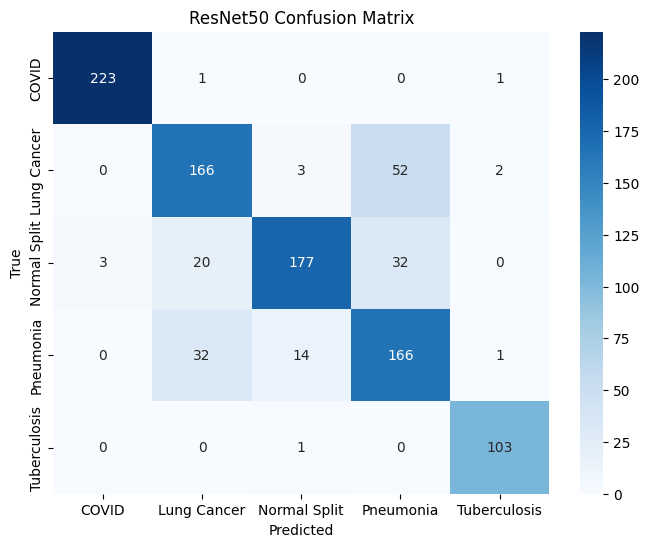

In [ ]:
# This cell loads the best model, evaluates it on the test set, and displays performance metrics.
ResNet_Model.load_state_dict(torch.load(Best_ResNet_Path, map_location = Device))
ResNet_Model.eval()

ResNet_Labels = []
ResNet_Preds = []

with torch.no_grad():
  for Images, Labels in tqdm(Test_Load):
    Images = Images.to(Device)
    Labels = Labels.to(Device)

    Outputs = ResNet_Model(Images)
    _, Preds = torch.max(Outputs, 1)

    ResNet_Labels.extend(Labels.cpu().numpy())
    ResNet_Preds.extend(Preds.cpu().numpy())

ResNet_Test_Accuracy = accuracy_score(ResNet_Labels, ResNet_Preds)
print("ResNet Test Accuracy:", ResNet_Test_Accuracy)
print()
print(classification_report(ResNet_Labels, ResNet_Preds, target_names=Class_Names))

ResNet_cm = confusion_matrix(ResNet_Labels, ResNet_Preds)

plt.figure(figsize =(8, 6))
sns.heatmap(ResNet_cm,
            annot = True,
            fmt = "d",
            cmap = "Blues",
            xticklabels = Class_Names,
            yticklabels = Class_Names
            )
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("ResNet50 Confusion Matrix")
plt.show()